# Future Trends and Research

## 📚 Learning Objectives

By completing this notebook, you will:
- Summarize trends in generative AI and multimodal models
- Connect current tools to research directions

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 1, lesson 02 "AI History" — the boom-and-winter pattern learned there is the frame for reading today's claims; Course 10 — Units 1-3 supply the technical baseline.

**Used later in:** Course 12 (AIAT 126) — Unit 1, whose literature review needs exactly this ability to place a paper.

---

## 🌍 Why this lesson exists — the trend line that broke in the same year it was drawn

This notebook fits a growth rate to publicly reported parameter counts. In 2022 — inside the very window being fitted — DeepMind published **Chinchilla** (Hoffmann et al., arXiv 2203.15556) and showed the axis was the wrong one. A **70-billion-parameter** model trained on **4× more data** at the same compute budget beat their own **280-billion-parameter** Gopher, reaching **67.5% on MMLU, a >7-point improvement**. Their conclusion: for every doubling of model size, the training tokens should double too. The landmark models on the plot below were not too small. They were undertrained.

**What goes wrong without this:** careers, budgets and curricula get planned on extrapolated trend lines. Knowing *why* a particular trend line broke — and being able to say it in one sentence — is most of the difference between professional judgement and repeating a press release.


## Real-World Context

Generative AI is the fastest-moving field in computing: capabilities that were research demos in
2020 (fluent long-form text, photoreal text-to-image) are consumer products today. This notebook
maps the **research directions driving that change**, grounds the biggest one — *scaling* — in a
small data exercise, and closes with a toy autoregressive model so you can connect today's tools
back to the mechanism they all share.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

## The Research Landscape — Five Directions to Watch

| Direction | What it means | Tools it already powers |
|---|---|---|
| **Scaling** | Bigger models + more data keep improving predictably ("scaling laws", Kaplan et al. 2020) | GPT-3/4, Claude, Gemini |
| **Multimodality** | One model across text, images, audio, video | GPT-4V-class models, Gemini |
| **Alignment** | Training models to follow instructions and human preferences (RLHF, Constitutional AI) | ChatGPT's leap over raw GPT-3 |
| **Efficiency** | Distillation, quantization, small open models that run locally | Llama/Mistral-class models, on-device AI |
| **Agents & tool use** | Models that plan, call tools/APIs, and act over many steps | Copilot-style coding agents |

Open research problems behind these: hallucination (models asserting falsehoods), long-horizon
reasoning, world models (learning how environments evolve), and evaluation itself — measuring
generative quality is still unsolved (you met FID/BLEU's limits in Units 1–2).

### Ground It in Data — the Scaling Trend

The clearest quantifiable trend is model size. Below we plot **publicly reported parameter
counts** of landmark language models and compute the growth rate from the data.
> **🔤 Which "agent" is this?** The row above uses **agent** in its 2026 sense — a language model
> that plans, calls tools, and acts over many steps. That is not a new definition: it is the same
> abstraction as Course 01 (AIAT 111), Unit 1, lesson 04 (perceive → think → act, Russell & Norvig,
> *AIMA* 4e, Ch. 2), with a language model in the `think` slot and tool calls as its actuators, and
> the same abstraction again as the reinforcement-learning agent of Course 09 (AIAT 123). One idea,
> three implementations. See `docs/GLOSSARY.md`.

Fitted growth rate: ~9x parameters per year (2018-2022 landmarks)
(Note: newer frontier models often do not disclose parameter counts,
 and research focus has partly shifted from raw size to data quality + efficiency.)


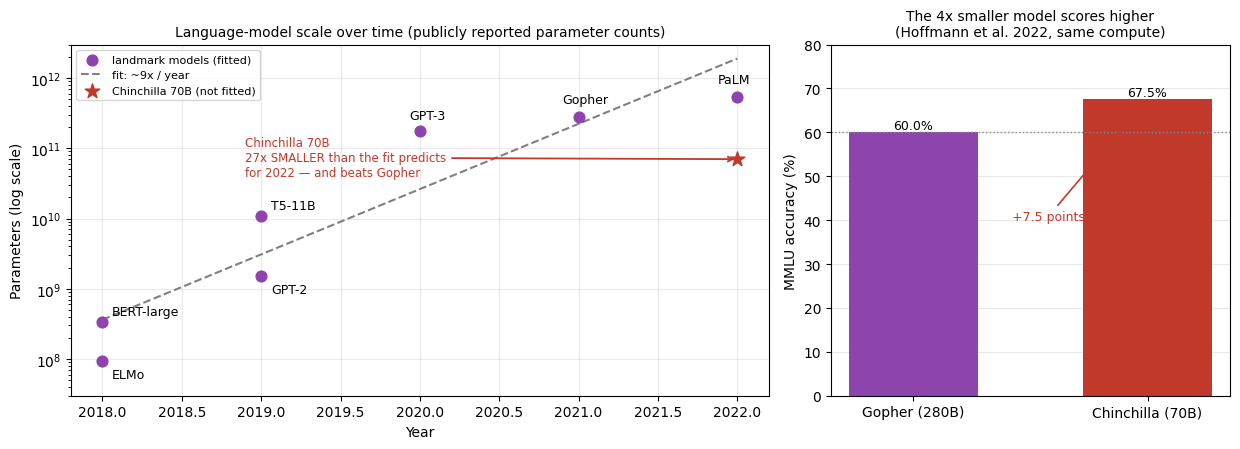


Trend line predicts ~1.90e+12 parameters for 2022; Chinchilla used 7.00e+10.
That is 27x fewer parameters — with a higher MMLU score than Gopher's 280B.


In [1]:
# Plot the scaling trend from publicly reported model sizes, and COMPUTE the growth
# rate from the data (rather than asserting it).
import numpy as np
import matplotlib.pyplot as plt

# ── Landmark language models: (name, year, parameters) — publicly reported counts ──
models = [
    ("ELMo",       2018, 9.4e7),
    ("BERT-large", 2018, 3.4e8),
    ("GPT-2",      2019, 1.5e9),
    ("T5-11B",     2019, 1.1e10),
    ("GPT-3",      2020, 1.75e11),
    ("Gopher",     2021, 2.8e11),
    ("PaLM",       2022, 5.4e11),
]
names  = [m[0] for m in models]
years  = np.array([m[1] for m in models], dtype=float)
params = np.array([m[2] for m in models])

# ── Fit exponential growth: straight line in log-space ────────────────────
slope, intercept = np.polyfit(years, np.log10(params), 1)
growth_per_year = 10 ** slope
print(f"Fitted growth rate: ~{growth_per_year:.0f}x parameters per year (2018-2022 landmarks)")
print("(Note: newer frontier models often do not disclose parameter counts,")
print(" and research focus has partly shifted from raw size to data quality + efficiency.)")

# ── The counterexample, published inside the fitted window ────────────────
# Hoffmann et al. 2022 (Chinchilla, arXiv 2203.15556): 70B params trained on 4x
# more data beat their own 280B Gopher. It is deliberately NOT part of the fit —
# it is the point the fit fails to predict.
CHINCHILLA = ("Chinchilla", 2022, 7.0e10)
MMLU = {"Gopher (280B)": 60.0, "Chinchilla (70B)": 67.5}   # reported in the same paper

# ── Plot: the trend on the left, the capability it mispredicts on the right ─
fig, (ax, ax_mmlu) = plt.subplots(1, 2, figsize=(12.5, 4.6),
                                  gridspec_kw={"width_ratios": [1.75, 1]})

ax.scatter(years, params, s=60, color='#8e44ad', zorder=3, label='landmark models (fitted)')
# label offsets nudged per-point so nothing sits on top of its own marker
offsets = {"ELMo": (7, -12), "BERT-large": (7, 5), "GPT-2": (7, -12), "T5-11B": (7, 5),
           "GPT-3": (-8, 9), "Gopher": (-12, 10), "PaLM": (-14, 10)}
for x, y, n in zip(years, params, names):
    ax.annotate(n, (x, y), textcoords="offset points", xytext=offsets[n], fontsize=9)
xs = np.linspace(years.min(), years.max(), 100)
ax.plot(xs, 10 ** (slope * xs + intercept), '--', color='gray',
        label=f'fit: ~{growth_per_year:.0f}x / year')

# the point that broke the axis
cx, cy = CHINCHILLA[1], CHINCHILLA[2]
on_trend = 10 ** (slope * cx + intercept)
ax.scatter([cx], [cy], s=120, marker='*', color='#c0392b', zorder=4,
           label='Chinchilla 70B (not fitted)')
ax.annotate(f"Chinchilla 70B\n{on_trend / cy:.0f}x SMALLER than the fit predicts\nfor 2022 — and beats Gopher",
            xy=(cx, cy), xytext=(2018.9, 4e10), fontsize=8.5, color='#c0392b',
            arrowprops=dict(arrowstyle="->", color='#c0392b', lw=1.3))
ax.set_yscale('log'); ax.set_ylim(3e7, 3e12)
ax.set_xlabel("Year"); ax.set_ylabel("Parameters (log scale)")
ax.set_title("Language-model scale over time (publicly reported parameter counts)", fontsize=10)
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.25)

# ── Right: same paper, same compute budget, opposite conclusion ───────────
bars = ax_mmlu.bar(list(MMLU), list(MMLU.values()), color=['#8e44ad', '#c0392b'], width=0.55)
for b, v in zip(bars, MMLU.values()):
    ax_mmlu.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.1f}%", ha='center', fontsize=9)
ax_mmlu.set_ylim(0, 80); ax_mmlu.set_ylabel("MMLU accuracy (%)")
ax_mmlu.set_title("The 4x smaller model scores higher\n(Hoffmann et al. 2022, same compute)", fontsize=10)
ax_mmlu.axhline(MMLU["Gopher (280B)"], ls=':', color='#7f8c8d', lw=1)
ax_mmlu.annotate(f"+{MMLU['Chinchilla (70B)'] - MMLU['Gopher (280B)']:.1f} points",
                 xy=(1, MMLU["Chinchilla (70B)"]), xytext=(0.42, 40), fontsize=9, color='#c0392b',
                 arrowprops=dict(arrowstyle="->", color='#c0392b', lw=1.2))
ax_mmlu.grid(axis='y', alpha=0.3); ax_mmlu.set_axisbelow(True)
plt.tight_layout(); plt.show()

print(f"\nTrend line predicts ~{on_trend:.2e} parameters for 2022; Chinchilla used {cy:.2e}.")
print(f"That is {on_trend / cy:.0f}x fewer parameters — with a higher MMLU score than Gopher's 280B.")

**Read the figure.**

*Left* — seven landmark models on a log parameter axis, and the straight line fitted through them.
The fit is honest about what it was given: those seven purple dots really do climb about 9× a year.
The red star is **Chinchilla**, published in 2022, inside the fitted window — and it sits far
*below* the line — well over an order of magnitude smaller than the trend says a 2022 frontier model
should be. The exact ratio is printed under the plot and repeated in the red annotation, computed
from the fit rather than asserted.

*Right* — why that star matters. Same paper, same compute budget: Chinchilla's 70B scores
**67.5%** on MMLU against Gopher's **60.0%** at 280B. The smaller bar on the parameter axis is the
taller bar on the capability axis.

Put the two panels together and you have the lesson: **the trend line was not wrong about its own
axis, it was fitted to the wrong axis.** Parameters were the quantity that was easy to publish, not
the quantity that was driving capability. When you extrapolate any curve in this field, the first
question is which axis someone chose to report.

## 🌍 Worked Example — the Mechanism Every Trend Builds On

All the tools in the table above — chatbots, coding agents, multimodal models — share one core
mechanism: **autoregressive next-token prediction**. To connect trends back to fundamentals, we
train a character-level language model (the same mechanism at ~1/1,000,000th of production scale):

- GitHub Copilot generates code token by token this way
- ChatGPT predicts each next token from all previous context
- The scaling trend you just plotted is *this exact model class*, grown by ~9 orders of magnitude

In [2]:
# Train a tiny character-level LSTM language model and generate text from it.
# WHY: this is the same autoregressive mechanism behind every model in the trends table,
# small enough to train in seconds on a CPU.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

# ── Vocabulary: map each character to an integer id ───────────────────────
chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]


# ── Dataset: every 20-char window predicts the next character ─────────────
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# ── A fixed 20-character context we re-photograph during training ─────────
# WHY: recording the loss at every step, and the model's next-character distribution
# at a few checkpoints, lets the next cell show training as a PROCESS instead of
# four printed numbers. In the source text this context is followed by "h" (…"that").
PROBE = "to be or not to be t"                 # exactly SEQ_LEN characters
probe_t = torch.tensor([[c2i[c] for c in PROBE]], dtype=torch.long)

def next_char_probs():
    """Model's probability distribution over the character after PROBE."""
    model.eval()
    with torch.no_grad():
        p = torch.softmax(model(probe_t)[0], dim=0).numpy()
    model.train()
    return p

# ── Training: 200 quick steps, a fresh random 256-window batch each time ──
CHECKPOINTS = [0, 25, 50, 100, 200]            # steps at which we photograph the model
losses, snapshots = [], []
for epoch in range(201):
    if epoch in CHECKPOINTS:
        snapshots.append((epoch, next_char_probs()))
    if epoch == 200:
        break                                   # step 200 is the final photograph only
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nSame autoregressive mechanism as ChatGPT — one token at a time,")
print("just ~6 orders of magnitude smaller, hence the garbled output.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or noteu a sa qfe the mes ind to sleep to sofe or to es and m a sleep to say we end the heartache and the 

Same autoregressive mechanism as ChatGPT — one token at a time,
just ~6 orders of magnitude smaller, hence the garbled output.


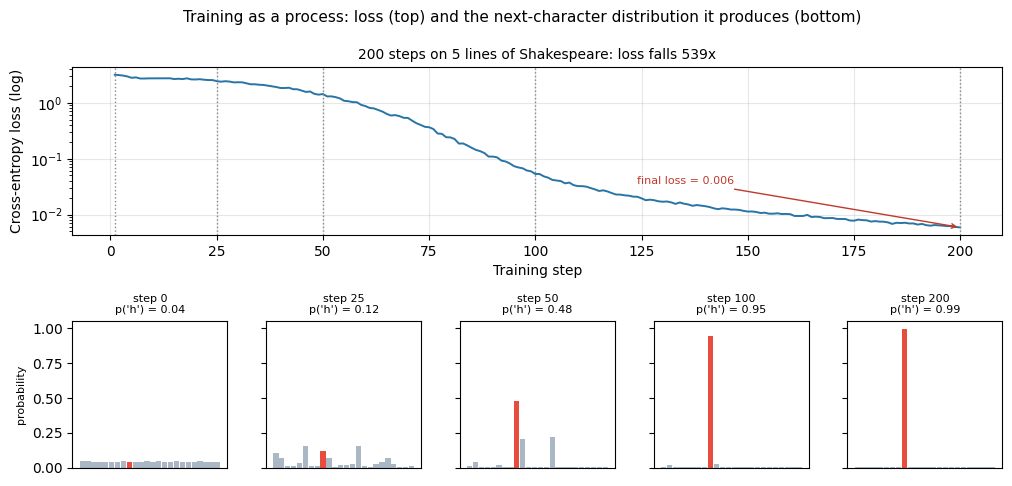

Context = "to be or not to be t"   (true next character: "h")
 step |     loss | top char |  p(top) | p(true)
    0 |    3.169 |      ' ' |    0.05 |    0.04
   25 |    2.380 |      'e' |    0.16 |    0.12
   50 |    1.298 |      'h' |    0.48 |    0.48
  100 |    0.053 |      'h' |    0.95 |    0.95
  200 |    0.006 |      'h' |    0.99 |    0.99


In [3]:
# Storyboard of the training run: the loss curve, plus the model's next-character
# distribution photographed at five steps. WHY: "loss 0.011 is memorisation, not learning"
# is a claim about a PROCESS — a frame grid is the honest way to show one in a notebook.
import matplotlib.pyplot as plt
import numpy as np

TRUE_NEXT = "h"                                   # the character that really follows PROBE
true_idx = c2i[TRUE_NEXT]

fig = plt.figure(figsize=(12, 5.2))
gs = fig.add_gridspec(2, len(snapshots), height_ratios=[1.15, 1], hspace=0.55, wspace=0.25)

# ── Top: the whole loss curve, with the five photograph points marked ─────
ax = fig.add_subplot(gs[0, :])
ax.plot(range(1, len(losses) + 1), losses, color="#2874a6", lw=1.4)
ax.set_yscale("log"); ax.set_xlabel("Training step"); ax.set_ylabel("Cross-entropy loss (log)")
ax.set_title(f"200 steps on 5 lines of Shakespeare: loss falls {losses[0] / losses[-1]:.0f}x",
             fontsize=10)
for step, _ in snapshots:                          # each line marks one frame below
    ax.axvline(max(step, 1), ls=":", color="#7f8c8d", lw=1)
ax.annotate(f"final loss = {losses[-1]:.3f}", xy=(len(losses), losses[-1]),
            xytext=(len(losses) * 0.62, losses[-1] * 6), fontsize=8, color="#c0392b",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1))
ax.grid(alpha=0.3)

# ── Bottom: the frame grid — P(next character | "to be or not to be t") ───
for col, (step, probs) in enumerate(snapshots):
    axf = fig.add_subplot(gs[1, col])
    colours = ["#e74c3c" if j == true_idx else "#aab7c4" for j in range(VOCAB)]
    axf.bar(range(VOCAB), probs, color=colours, width=0.9)
    axf.set_ylim(0, 1.05); axf.set_xticks([])
    axf.set_title(f"step {step}\np('{TRUE_NEXT}') = {probs[true_idx]:.2f}", fontsize=8)
    if col == 0:
        axf.set_ylabel("probability", fontsize=8)
    else:
        axf.set_yticklabels([])
fig.suptitle("Training as a process: loss (top) and the next-character distribution it produces (bottom)",
             fontsize=11, y=0.99)
plt.show()

# ── The same storyboard as a printed step table ───────────────────────────
print(f'Context = "{PROBE}"   (true next character: "{TRUE_NEXT}")')
print(f"{'step':>5} | {'loss':>8} | {'top char':>8} | {'p(top)':>7} | {'p(true)':>7}")
for step, probs in snapshots:
    loss_here = losses[step] if step < len(losses) else losses[-1]
    top = int(np.argmax(probs))
    print(f"{step:>5} | {loss_here:8.3f} | {i2c[top]!r:>8} | {probs[top]:7.2f} | {probs[true_idx]:7.2f}")


**Read the figure.**

*Top* — the full 200-step loss curve on a log axis, with the five points where we photographed
the model marked. It does not plateau at a useful value; it keeps falling, because there is
nothing left to generalise to. Five lines of Shakespeare fit in the weights.

*Bottom* — the same run seen from inside. Each panel is the model's probability distribution
over the **next character** after the fixed context `"to be or not to be t"`; the red bar is the
character that actually follows in the training text. At step 0 the mass is spread across the
alphabet — the model has no opinion. By the last frame nearly all of it sits on one bar. That
collapse — printed step by step in the table underneath — is what a training loss of a few
thousandths *looks* like, and it is the picture of a model that has stored its training text
rather than learned English.

This is the caution under the scaling plot above, made visual: **a falling loss curve is evidence
about your corpus before it is evidence about your model.**

## 💬 Discuss

1. Our fit says **~9× parameters per year across 2018–2022**, and Chinchilla says those same models were undertrained. Is the fitted line *wrong*, or is it right about the wrong quantity? What would you have plotted instead if you had known?
2. Frontier labs largely stopped disclosing parameter counts after 2022 — the printed note says so. What does that do to this plot, and what measurable quantity would you fit instead to brief a client in 2026?
3. The toy LSTM below reaches a loss of **0.011** on a short passage and still emits garbage. What does that tell you about using training loss as evidence for any claim about the trend you just plotted?


## ⚠️ Where this breaks

**Extrapolating a four-point trend is not forecasting.** The plot ends in 2022 precisely because the reported quantity stopped being published — and a trend line that cannot be updated cannot be validated, only believed.

**Parameter count is not capability.** Chinchilla-optimal data scaling, data quality, instruction tuning, and inference-time compute all move capability without moving the plotted axis. Since DeepSeek-R1 (arXiv 2501.12948) it has been routine to buy reasoning at inference time instead of at training time — a capability gain that this chart would record as flat.

**The toy model's loss of 0.011 is memorisation, not learning.** A short repeated corpus can be driven to near-zero loss in seconds. Any argument about scaling built on training loss is really an argument about how repetitive the text was — example 06 of Unit 2 measures exactly that.

**Trend lists age badly, including this one.** The five directions in the table are a reasonable 2026 map. Treat the specific tool names as perishable and the *mechanism* — next-token prediction, everywhere — as the durable part.


## 📝 Summary

In this notebook, you:

- Surveyed the five research directions shaping generative AI — **scaling, multimodality,
  alignment, efficiency, and agents** — and the open problems behind them (hallucination,
  reasoning, evaluation)
- **Computed the scaling trend** from publicly reported model sizes (~an order-of-magnitude
  parameter growth per year across 2018–2022 landmark models)
- Trained a toy autoregressive character model to connect every trend back to the shared
  mechanism: next-token prediction

## 🔭 State of the field (2026)

The five directions in the table above are still the right five, but two of them changed shape after this notebook's 2018–2022 fitting window closed. **Scaling** became a question of *where* to spend compute rather than how many parameters to buy — allocating more compute per question at inference time can beat training a larger model (Snell et al. 2024, arXiv 2408.03314) — and DeepSeek-R1 showed that large-scale RL with verifiable rewards produces long deliberate reasoning as an openly documented training outcome (DeepSeek-AI 2025, arXiv 2501.12948). **Multimodality** stopped meaning "one model that reads several modalities" and started meaning *unified* understanding and generation inside a single architecture (Zhao et al. 2025, arXiv 2505.02567), while video moved from short clips to open long-form models (Meituan LongCat Team 2025, arXiv 2510.22200) and, in 2026, toward enterable world models — the "world models" open problem this notebook names, built (Zhang et al. 2026, arXiv 2608.23189).

None of that weakens the exercise you just ran; it is the reason to run it. The durable subject here is not the 9×-per-year figure — it is the habit of asking **which axis someone chose to report** before extrapolating anything, and Chinchilla remains the cleanest worked example of that habit in the literature. The toy autoregressive model is equally unchanged in relevance: next-token prediction is still the shared mechanism underneath the reasoning models, the unified multimodal models and the video models alike.

## 📚 References & Further Reading

**Papers:**
- Radford et al. (2019) — [GPT-2: Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- Brown et al. (2020) — [GPT-3](https://arxiv.org/abs/2005.14165)
- Bommasani et al. (2021) — [On the Opportunities and Risks of Foundation Models](https://arxiv.org/abs/2108.07258) *(the survey that named the "foundation model" era)*

**Recent (2024–2026) — where the five directions actually went:**
- Snell et al. (2024) — [Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters](https://arxiv.org/abs/2408.03314) *(scaling became a compute-allocation decision at inference, not only at training)*
- DeepSeek-AI (2025) — [DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning](https://arxiv.org/abs/2501.12948) *(open, documented reasoning model; the direction the table calls "alignment" and "agents" now runs through)*
- Zhao et al. (2025) — [Unified Multimodal Understanding and Generation Models: Advances, Challenges, and Opportunities](https://arxiv.org/abs/2505.02567) *(the orientation survey for the multimodality row)*
- Meituan LongCat Team (2025) — [LongCat-Video Technical Report](https://arxiv.org/abs/2510.22200) *(open long-form video generation with a published recipe)*
- Zhang et al. (2026) — [EchoWM: Open and Enterable Omnimodal World Models](https://arxiv.org/abs/2608.23189) *(the "world models" open problem named above, as a 2026 system)*
- Nguyen et al. (2024) — [A Survey of Small Language Models](https://arxiv.org/abs/2410.20011) *(the "efficiency" row of the table above, organised: the design space of models small enough to run on the hardware you own)*
- Guo et al. (2026) — [From Question Answering to Task Completion: A Survey on Agent System and Harness Design](https://arxiv.org/abs/2606.20683) *(the "agents & tool use" row in its 2026 form: the model and the harness around it, designed together)*

**Interactive:**
- [Karpathy's nanoGPT](https://github.com/karpathy/nanoGPT) — build GPT in 300 lines
- [The Unreasonable Effectiveness of RNNs](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

**State-of-the-Art:** GPT-4, Claude 3.5, Gemini 1.5 — all trained on trillions of tokens with transformer decoders.